In [120]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import numpy as np

In [121]:

cluster_folders = {
    "gassing": Path("Cluster_0 (gassing)"),
    "cracking": Path("Cluster_1 (cracking)"),
    "mixed": Path("Cluster_2 (mix undecided)")
}

cluster_data = {
    cluster: {
        csv_file.stem: pd.read_csv(csv_file)
        for csv_file in sorted(folder.glob("*.csv"))
    }
    for cluster, folder in cluster_folders.items()
}

In [122]:
time_threshold = 0.00005
noise_data = {}
signal_data = {}

for cluster_name, file_data in cluster_data.items():
    noise_data[cluster_name] = {}
    signal_data[cluster_name] = {}

    for file_name, dataframe in file_data.items():
        noise_mask = dataframe["Time (s)"] < time_threshold
        signal_mask = dataframe["Time (s)"] >= time_threshold
        noise_data[cluster_name][file_name] = dataframe.loc[noise_mask].copy()
        signal_data[cluster_name][file_name] = dataframe.loc[signal_mask].copy()

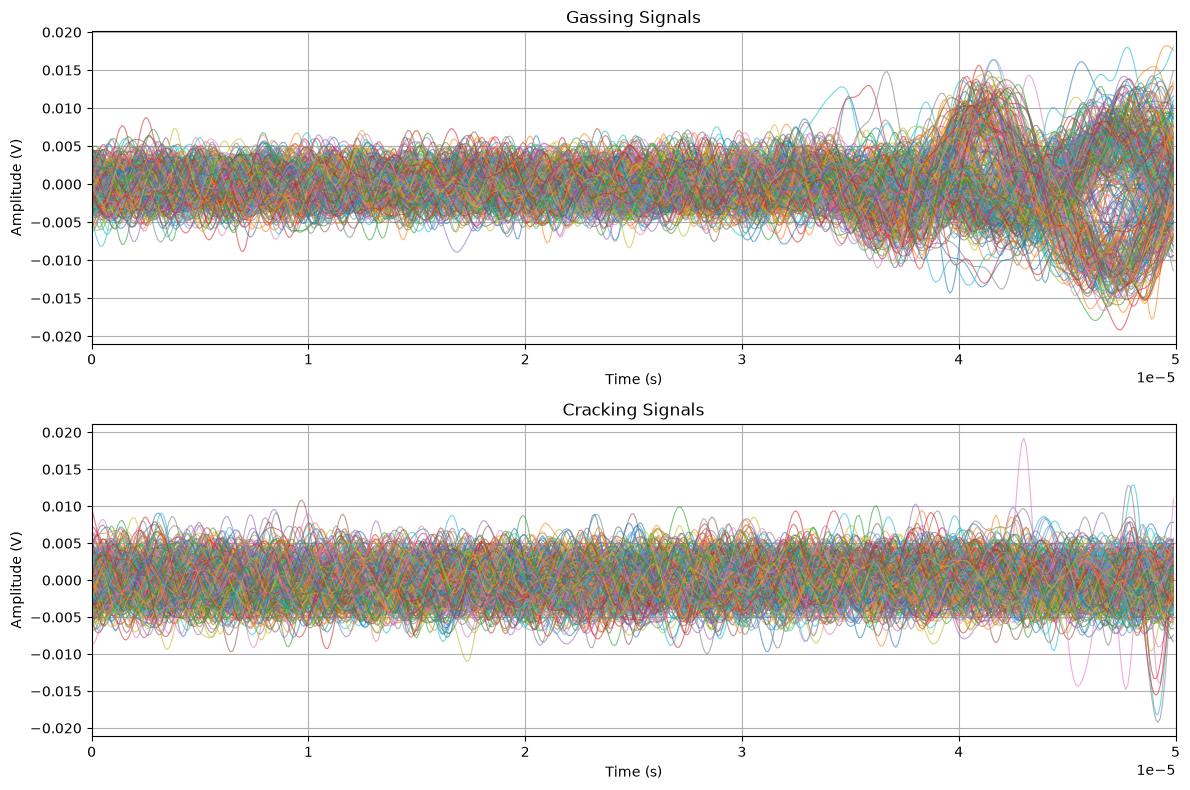

In [166]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

for key in noise_data["gassing"]:
    noise_data["gassing"][key].plot(
        x="Time (s)",
        y="Amplitude (V)",
        ax=ax[0],
        legend=False,
        alpha=0.6,      
        linewidth=0.8
    )

for key in noise_data["cracking"]:
    noise_data["cracking"][key].plot(
        x="Time (s)",
        y="Amplitude (V)",
        ax=ax[1],
        legend=False,
        alpha=0.6,
        linewidth=0.8
    )

ax[0].set_xlim(0.0000, 0.00005)
ax[0].set_title("Gassing Signals")
ax[0].set_ylabel("Amplitude (V)")
ax[0].grid(True)

ax[1].set_xlim(0.0000, 0.00005)
ax[1].set_title("Cracking Signals")
ax[1].set_ylabel("Amplitude (V)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [124]:
all_noise =  noise_data["cracking"]#| noise_data["mixed"]

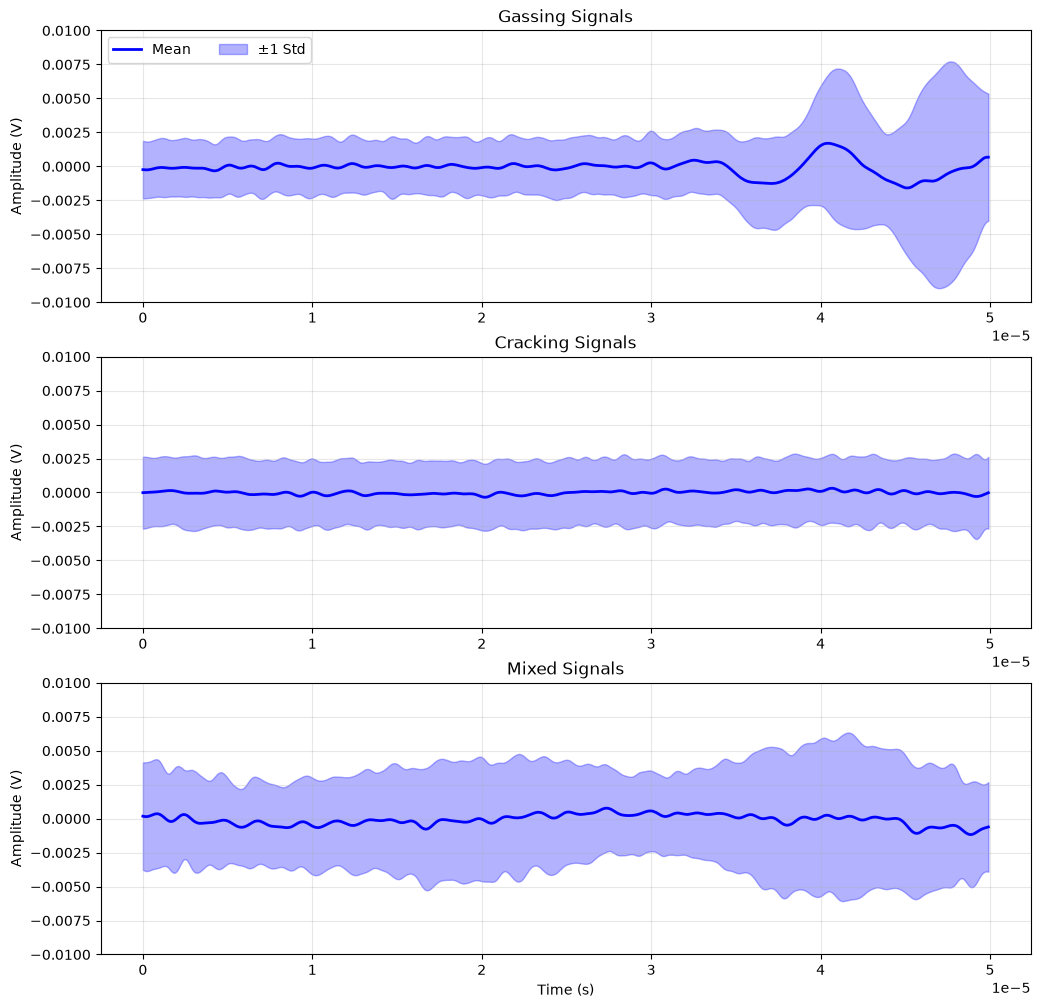

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12, 12))
class_lst = ["gassing", "cracking", "mixed"]
for i, c in enumerate(class_lst):
    signals = np.array([
    df["Amplitude (V)"].values
    for df in noise_data[c].values()
    ])

    time = next(iter(noise_data[c].values()))["Time (s)"].values

    mean_signal = signals.mean(axis=0)
    std_signal = signals.std(axis=0)

    # Plot
    # plt.figure(figsize=(12, 4))

    ax[i].plot(
    time,
    mean_signal,
    color="blue",
    linewidth=2,
    label="Mean"
    )

    ax[i].fill_between(
    time,
    mean_signal - std_signal,
    mean_signal + std_signal,
    color="blue",
    alpha=0.3,
    label="±1 Std"
    )
    percentiles = np.array(range(70, 100, 5))
    colors = plt.cm.viridis(np.linspace(0, 1, len(percentiles)))
    first_crossing_time_lst = []
    # for p, color in zip(percentiles, colors):

    #     threshold = np.percentile(std_signal, p)

    #     idx = np.where(std_signal > threshold)[0]

    #     if len(idx) > 0:
    #         first_crossing_time = time[idx[0]]
    #         first_crossing_time_lst.append(first_crossing_time) 
    #     else:
    #         first_crossing_time_lst.append(0) 
    #     ax[i].axvline(
    #     first_crossing_time,
    #     color=color,
    #     linestyle="--",
    #     alpha=0.8,
    #     label=f"{p}%"
    #     )
    first_crossing_time_lst = np.array(first_crossing_time_lst)
    ax[i].set_ylabel("Amplitude (V)")
    ax[i].set_title(c.capitalize() + " Signals")
    ax[i].grid(alpha=0.3)
    ax[i].set_ylim(-0.01, 0.01)
ax[-1].set_xlabel("Time (s)")
ax[0].legend(ncol=4)
plt.show()

In [126]:
all_noise_filtered = {}
for key in all_noise.keys():
    all_noise_filtered[key] = all_noise[key]#[all_noise[key]["Time (s)"]<=first_crossing_time_lst[percentiles==75][0]]

In [127]:
def run_fft_df(input_df, N_target=362):
    time = input_df['Time (s)'].values
    amplitude = input_df['Amplitude (V)'].values[:N_target]
    
    N = len(amplitude)
    dt = time[1] - time[0] 
    
    amp_detrend = amplitude 
    
    fft_vals = np.fft.rfft(amp_detrend)
    freqs = np.fft.rfftfreq(N, d=dt) / 1e3 # kHz 변환
    magnitude = np.abs(fft_vals) / N

    if N % 2 == 0:
        magnitude[1:-1] *= 2 
    else:
        magnitude[1:] *= 2   
    return freqs / 1e3, magnitude

def run_fft(input_dict, N_target=362):
    freq_lst = []
    magnitude_lst = []
    for key, df in input_dict.items():
            freqs, magnitude = run_fft_df(df, N_target)
            freq_lst.append(freqs)
            magnitude_lst.append(magnitude)
    return np.array(freq_lst) / 1e3, np.array(magnitude_lst)

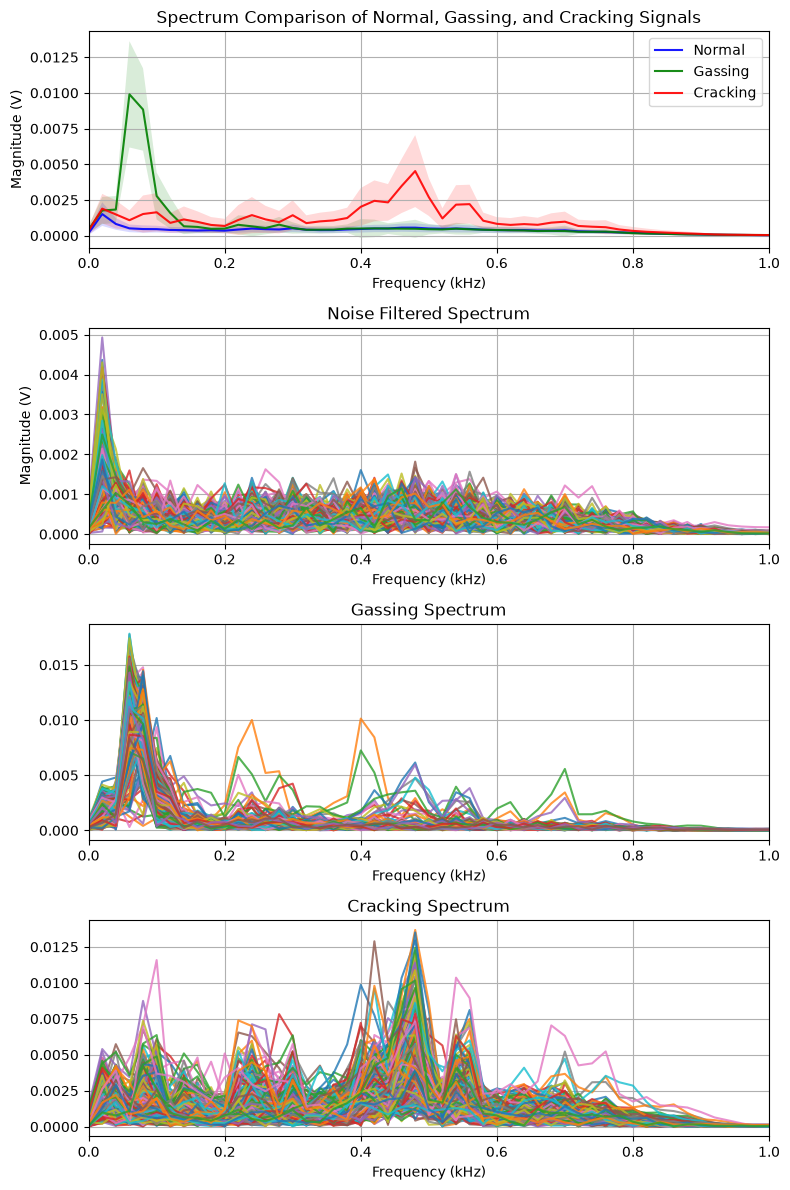

In [193]:
fig, ax = plt.subplots(4,1, figsize=(8, 12))

N = 500
# 2. noise
noise_freq_lst, noise_magnitude_lst = [], []
gassing_freq_lst, gassing_magnitude_lst = [], []
cracking_freq_lst, cracking_magnitude_lst = [], []

for key in all_noise_filtered:
    noise_freqs, noise_magnitude = run_fft_df(all_noise_filtered[key], N_target=N)
    noise_freq_lst.append(noise_freqs)
    noise_magnitude_lst.append(noise_magnitude)
for key in signal_data['gassing']:
    gassing_freqs, gassing_magnitude = run_fft_df(signal_data['gassing'][key], N_target=N)
    gassing_freq_lst.append(gassing_freqs)
    gassing_magnitude_lst.append(gassing_magnitude)
for key in signal_data['cracking']:
    cracking_freqs, cracking_magnitude = run_fft_df(signal_data['cracking'][key], N_target=N)
    cracking_freq_lst.append(cracking_freqs)
    cracking_magnitude_lst.append(cracking_magnitude)


freq_normal = noise_freq_lst[0]
freq_gassing = gassing_freq_lst[0]
freq_cracking = cracking_freq_lst[0]

noise_magnitude_lst = np.array(noise_magnitude_lst)
gassing_magnitude_lst = np.array(gassing_magnitude_lst)
cracking_magnitude_lst = np.array(cracking_magnitude_lst)

mean_normal = noise_magnitude_lst.mean(axis=0)
std_normal = noise_magnitude_lst.std(axis=0)

mean_gassing = gassing_magnitude_lst.mean(axis=0)
std_gassing = gassing_magnitude_lst.std(axis=0)

mean_cracking = cracking_magnitude_lst.mean(axis=0)
std_cracking = cracking_magnitude_lst.std(axis=0)

ax[0].plot(freq_normal, mean_normal, color='blue', alpha=0.9, label='Normal', linewidth=1.5)
ax[0].fill_between(freq_normal, mean_normal - std_normal, mean_normal + std_normal, 
                    color='blue', alpha=0.15, edgecolor='none')

# 4. Gassing (Green) 
ax[0].plot(freq_gassing, mean_gassing, color='green', alpha=0.9, label='Gassing', linewidth=1.5)
ax[0].fill_between(freq_gassing, mean_gassing - std_gassing, mean_gassing + std_gassing, 
                    color='green', alpha=0.15, edgecolor='none')

# 5. Cracking (Red) 
ax[0].plot(freq_cracking, mean_cracking, color='red', alpha=0.9, label='Cracking', linewidth=1.5)
ax[0].fill_between(freq_cracking, mean_cracking - std_cracking, mean_cracking + std_cracking, 
                    color='red', alpha=0.15, edgecolor='none')

# 6. 레이아웃 및 축 설정
ax[0].set_xlim(0, 1)
ax[0].set_title('Spectrum Comparison of Normal, Gassing, and Cracking Signals')
ax[0].set_xlabel('Frequency (kHz)')
ax[0].set_ylabel('Magnitude (V)')
ax[0].grid(True)
ax[0].legend()


ax[1].plot(freq_normal, noise_magnitude_lst.T, alpha=0.8)
ax[1].set_xlim(0, 1)
ax[1].set_title('Noise Filtered Spectrum')
ax[1].set_xlabel('Frequency (kHz)')
ax[1].set_ylabel('Magnitude (V)')
ax[1].grid(True)

# 3. gassing
ax[2].plot(freq_gassing, gassing_magnitude_lst.T, alpha=0.8)
ax[2].set_xlim(0, 1)
ax[2].set_title('Gassing Spectrum')
ax[2].set_xlabel('Frequency (kHz)')
ax[2].grid(True)

# 4.  cracking
ax[3].plot(freq_cracking, cracking_magnitude_lst.T, alpha=0.8)
ax[3].set_xlim(0, 1)
ax[3].set_title('Cracking Spectrum')
ax[3].set_xlabel('Frequency (kHz)')
ax[3].grid(True)

plt.tight_layout()
plt.show()

In [129]:
X = np.vstack([noise_magnitude_lst, gassing_magnitude_lst, cracking_magnitude_lst])
y = np.array([0]*len(noise_magnitude_lst) + [1]*len(gassing_magnitude_lst) + [2]*len(cracking_magnitude_lst))


In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testset size: {X_test.shape[0]}")


Training set size: 1009
Testset size: 113


In [131]:
X_train.shape

(1009, 251)

In [132]:
model=GaussianNB()
model.fit(X_train, y_train)
accuracy = model.score(X_train, y_train) 
print("Training Accuracy:", accuracy)
accuracy = model.score(X_test, y_test)
print("Test Accuracy:", accuracy)

Training Accuracy: 0.9355797819623389
Test Accuracy: 0.8938053097345132


In [133]:
sample_fft = X_test[0:1]
probabilities = model.predict_proba(sample_fft)[0]

In [134]:
result_dict = {}
prob_dict = {}
magnitude_input = {}

for key in cluster_data["mixed"]:
    result_dict[key] = []
    magnitude_input[key] = []
    prob_dict[key] = []
    df = cluster_data["mixed"][key]
    
    for i in range(0, len(df) - N + 1, N):
        window_df = df.iloc[i : i + N]
        
        freq, magnitude = run_fft_df(window_df, N_target=N)
        
        if len(magnitude) > model.n_features_in_:
            curr_mag = magnitude[:model.n_features_in_]
        else:
            curr_mag = magnitude
            
        magnitude_input[key].append(curr_mag)
            
        prob = model.predict_proba(np.array(curr_mag).reshape(1, -1))[0]
        result_dict[key].append(prob)
        prob_dict[key].append(prob)
        
    result_dict[key] = np.array(result_dict[key]).argmax(axis=1)

/scratch/ipykernel_2953247/3899310108.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(t_start, t_end, color=color, alpha=0.25, edgecolor='none', label=label)


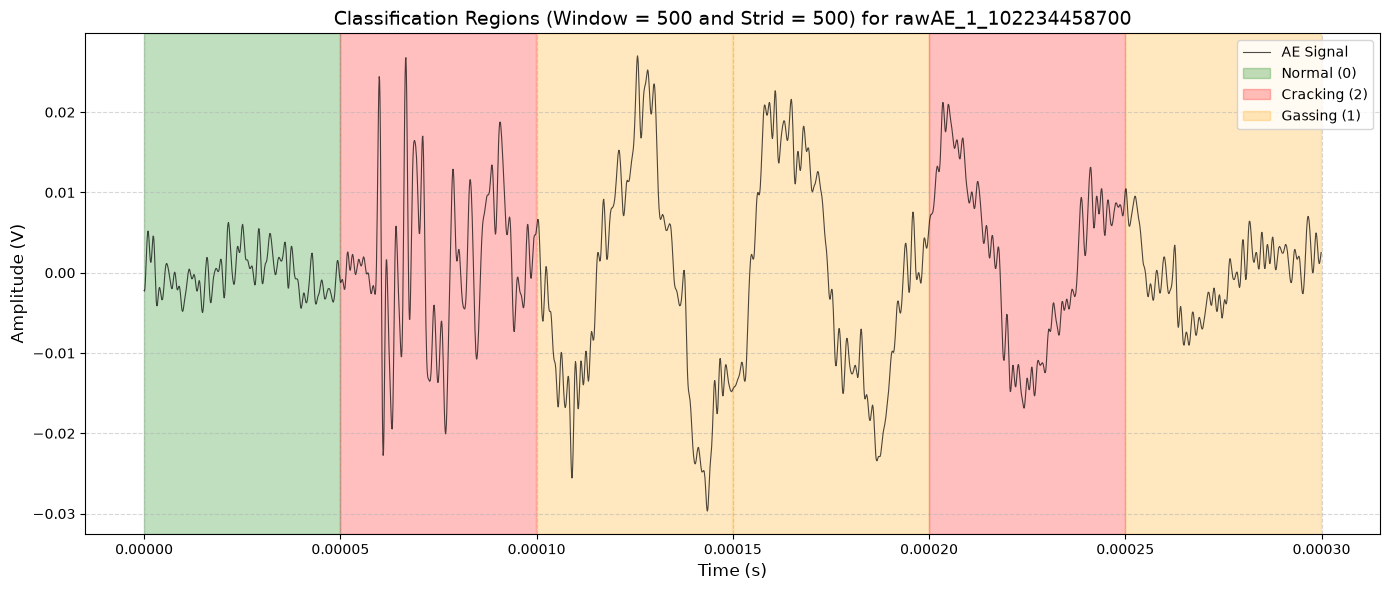

In [194]:
key = list(result_dict.keys())[0]
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

df = cluster_data["mixed"][key]
time_arr = df['Time (s)'].values
amp_arr = df['Amplitude (V)'].values

ax.plot(time_arr, amp_arr, color='black', linewidth=0.8, alpha=0.7, label='AE Signal')

color_map = {0: 'green', 1: 'orange', 2: 'red'}
label_map = {0: 'Normal (0)', 1: 'Gassing (1)', 2: 'Cracking (2)'}
used_labels = set()

for idx, cls_id in enumerate(result_dict[key]):
    i = idx * N  
    
    t_start = time_arr[i]
    t_end = time_arr[i + N - 1] if (i + N - 1) < len(time_arr) else time_arr[-1]
    
    color = color_map.get(cls_id, 'gray')
    label = label_map.get(cls_id, f'Class {cls_id}') if cls_id not in used_labels else None
    
    ax.axvspan(t_start, t_end, color=color, alpha=0.25, edgecolor='none', label=label)
    used_labels.add(cls_id)

# ax.set_xlim(0.00005*2, 0.00005*4)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (V)', fontsize=12)
ax.set_title(f'Classification Regions (Window = {N} and Strid = {N}) for {key}', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

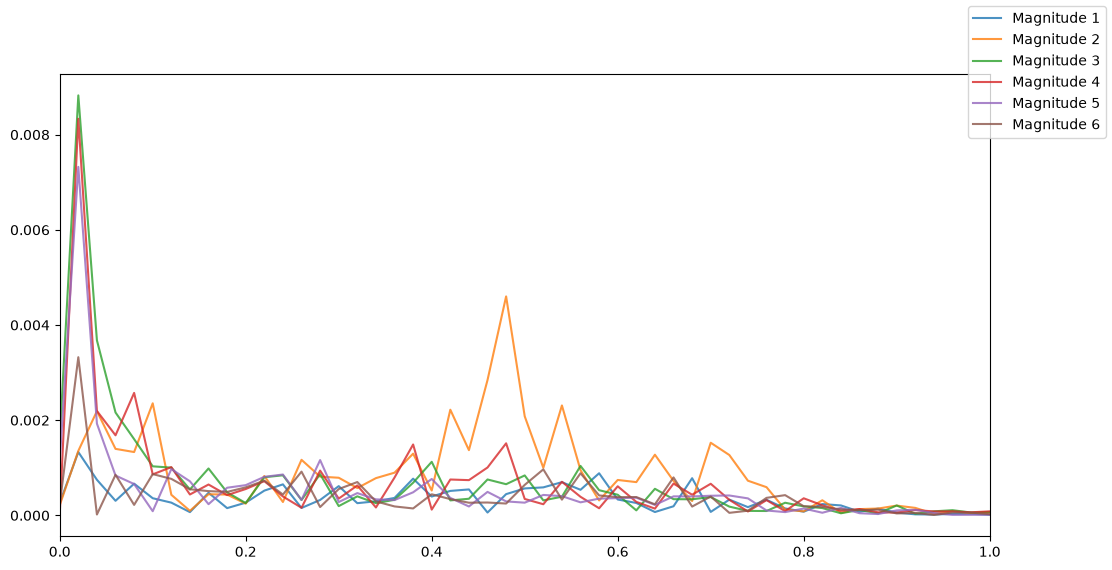

In [141]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
for i, mag in enumerate(magnitude_input[key]):
    ax.plot(freq_normal, mag, alpha=0.8, label = f'Magnitude {i+1}')
ax.set_xlim(0, 1)
fig.legend()
plt.show()

In [137]:
result_dict[key]

array([0, 2, 0, 1, 0, 0])